# **Proyek Klasifikasi Gambar: Penyakit pada Daun Padi**
- **Nama:** Fitri Hartanti
- **Email:** mc008d5x2339@student.devacademy.id
- **ID Dicoding:** MC008D5X2339

## **Objective:**   
Membangun sebuah model menggunakan CNN yang dapat mengklasifikasikan penyakit pada daun padi dengan menggunakan gambar daun padi.

## **Sumber Dataset**
https://www.kaggle.com/datasets/loki4514/rice-leaf-diseases-detection

# **Import Libraries**

In [2]:
# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import splitfolders

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
datagen = ImageDataGenerator()

# **Data Loading and Data Preparation**

In [24]:
path_to_dataset = "Rice_Leaf_AUG"

# Hitung total gambar
total_images = 0
for root, dirs, files in os.walk(path_to_dataset):
    total_images += len([file for file in files if file.endswith(('.png', '.jpg', '.jpeg'))])

print(f"Total jumlah gambar dalam dataset: {total_images}")

Total jumlah gambar dalam dataset: 11790


In [ ]:
# Path ke folder dataset
input_folder = "Rice_Leaf_AUG"

# Output folder di mana folder train dan val akan disimpan
output_folder = "SPLIT"

# Memisahkan dataset (70% train, 20% val, 10% test)
splitfolders.ratio(input=input_folder, output=output_folder, seed=42, ratio=(0.7, 0.2, 0.1), group_prefix=None)

# Struktur output:
# output_folder/
#     train/
#         bacterial_leaf_blight/
#         brown_spot/
#         healthy/
#         leaf_blast/
#         leaf_scald/
#         narrow_brown_spot/
#         Neck_Blast/
#         Rice Hispa/
#         Sheath Blight/
#         Tungro/
#     val/
#         bacterial_leaf_blight/
#         brown_spot/
#         healthy/
#         leaf_blast/
#         leaf_scald/
#         narrow_brown_spot/
#         Neck_Blast/
#         Rice Hispa/
#         Sheath Blight/
#         Tungro/
#     test/
#         bacterial_leaf_blight/
#         brown_spot/
#         healthy/
#         leaf_blast/
#         leaf_scald/
#         narrow_brown_spot/
#         Neck_Blast/
#         Rice Hispa/
#         Sheath Blight/
#         Tungro/


In [4]:
Image_Size= 224
Batch_Size = 32
Channels=3

In [ ]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "SPLIT/train",
    shuffle=True,
    image_size = (Image_Size,Image_Size),
    batch_size=Batch_Size
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    "SPLIT/test",
    shuffle=True,
    image_size = (Image_Size,Image_Size),
    batch_size=Batch_Size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "SPLIT/val",
    shuffle=True,
    image_size = (Image_Size,Image_Size),
    batch_size=Batch_Size
)

Found 8249 files belonging to 9 classes.
Found 1187 files belonging to 9 classes.
Found 2354 files belonging to 9 classes.


In [4]:
class_names = train_data.class_names
class_names

['Bacterial Leaf Blight',
 'Brown Spot',
 'Healthy Rice Leaf',
 'Leaf Blast',
 'Leaf scald',
 'Narrow Brown Leaf Spot',
 'Neck_Blast',
 'Rice Hispa',
 'Sheath Blight']

In [5]:
n_classes = len(class_names)
n_classes

9

Ukuran paling umum:
width  height
224    224       6287
1600   1200      1183
3120   3120       699
4000   3000        24
2160   3840        13
Name: count, dtype: int64


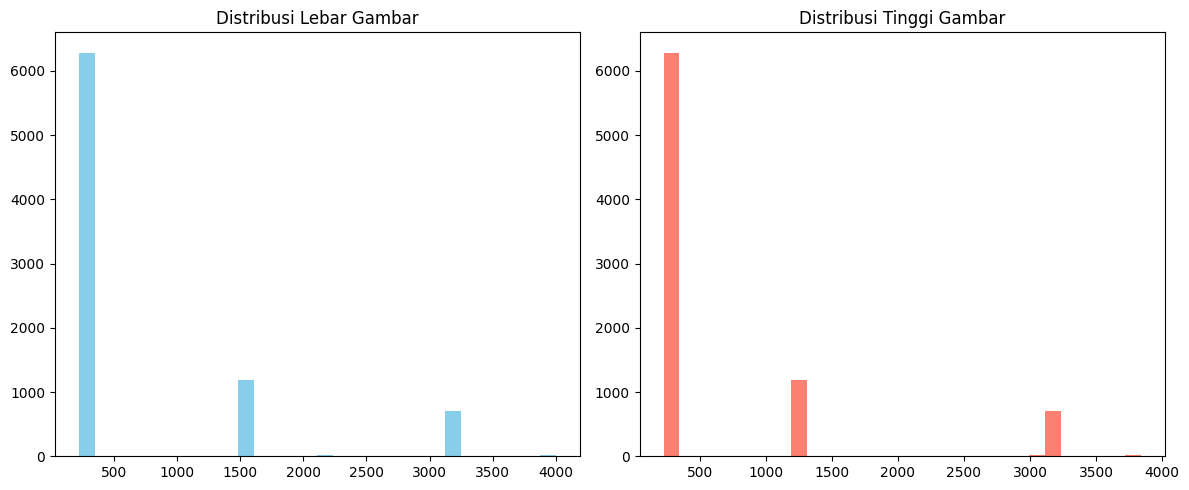

In [14]:
sizes = []

# Ambil dimensi semua gambar
for path, _, files in os.walk("SPLIT/train"):
    for file in files:
        if file.lower().endswith(('jpg', 'png', 'jpeg')):
            img_path = os.path.join(path, file)
            with Image.open(img_path) as img:
                sizes.append(img.size)  # (width, height)

# Konversi ke DataFrame
df_sizes = pd.DataFrame(sizes, columns=['width', 'height'])

# Tampilkan 5 dimensi yang paling sering muncul
print("Ukuran paling umum:")
print(df_sizes.value_counts().head())

# Plot distribusi lebar dan tinggi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_sizes['width'], bins=30, color='skyblue')
plt.title("Distribusi Lebar Gambar")

plt.subplot(1, 2, 2)
plt.hist(df_sizes['height'], bins=30, color='salmon')
plt.title("Distribusi Tinggi Gambar")

plt.tight_layout()
plt.show()


In [6]:
for image_batch, label_batch in train_data.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 224, 224, 3)
[2 6 1 6 2 1 1 3 8 1 7 8 5 8 1 6 4 7 7 8 7 7 8 8 0 2 5 4 8 6 2 0]


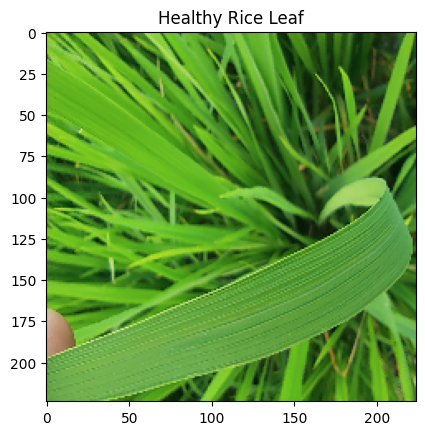

In [7]:
for image_batch, label_batch in train_data.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(class_names[label_batch[0]])

# **Plot Distribution**

labels
Leaf Blast                1223
Sheath Blight             1140
Brown Spot                1082
Leaf scald                 932
Rice Hispa                 909
Bacterial Leaf Blight      837
Healthy Rice Leaf          759
Neck_Blast                 700
Narrow Brown Leaf Spot     667
Name: count, dtype: int64


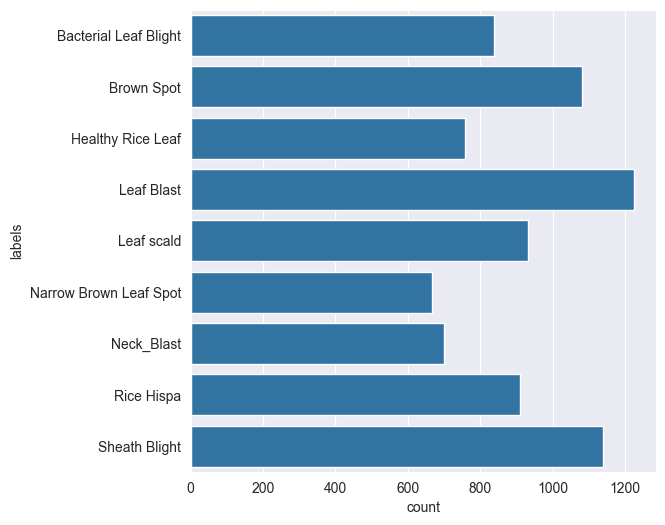

In [15]:
# Define source path
lung_path = "SPLIT/train"

# Create a list that stores data for each filenames, filepaths, and labels in the data
file_name = []
labels = []
full_path = []

# Get data image filenames, filepaths, labels one by one with looping, and store them as dataframe
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))  # FIX: gunakan os.path.basename untuk ambil nama folder
        file_name.append(name)

distribution = pd.DataFrame({"path": full_path, 'file_name': file_name, "labels": labels})

# Menampilkan jumlah gambar per kelas
print(distribution['labels'].value_counts())

# Plot the distribution of images across the classes
Label = distribution['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)


# **Modelling**

In [4]:
from tensorflow.keras import layers, models
import tensorflow as tf

# Parameter model
Image_Size = 224  # Ukuran input gambar
Channels = 3
n_classes = 9

# Arsitektur CNN dasar menggunakan Sequential, Conv2D, dan Pooling
model_cnn = models.Sequential()

# Layer konvolusi pertama
model_cnn.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(Image_Size, Image_Size, Channels)))
model_cnn.add(layers.BatchNormalization())
model_cnn.add(layers.Activation('relu'))
model_cnn.add(layers.MaxPooling2D((2, 2)))

# Layer konvolusi kedua
model_cnn.add(layers.Conv2D(64, (3, 3), padding='same'))
model_cnn.add(layers.BatchNormalization())
model_cnn.add(layers.Activation('relu'))
model_cnn.add(layers.MaxPooling2D((2, 2)))

# Layer konvolusi ketiga
model_cnn.add(layers.Conv2D(128, (3, 3), padding='same'))
model_cnn.add(layers.BatchNormalization())
model_cnn.add(layers.Activation('relu'))
model_cnn.add(layers.MaxPooling2D((2, 2)))

# Flatten dan Dense layers
model_cnn.add(layers.Flatten())
model_cnn.add(layers.Dense(256))
model_cnn.add(layers.BatchNormalization())
model_cnn.add(layers.Activation('relu'))
model_cnn.add(layers.Dense(n_classes, activation='softmax'))

# Kompilasi model
model_cnn.compile(optimizer='adam', 
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), 
                  metrics=['accuracy'])

# Asumsikan train_data sudah didefinisikan seperti sebelumnya
for image_batch, label_batch in train_data.take(1):
    model_cnn(image_batch)

# Menampilkan arsitektur model
model_cnn.summary()


c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,787,849 (98.37 MB)

 Trainable params: 25,786,889 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
# Menambahkan Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [ ]:
# Melatih model
history_model = model_cnn.fit(train_data, 
                                validation_data=val_data, 
                                epochs=60, 
                                callbacks=[early_stopping])

Epoch 1/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 228s 875ms/step - accuracy: 0.5368 - loss: 1.4285 - val_accuracy: 0.5106 - val_loss: 1.5018
Epoch 2/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 227s 880ms/step - accuracy: 0.7708 - loss: 0.6659 - val_accuracy: 0.6975 - val_loss: 0.8892
Epoch 3/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 232s 899ms/step - accuracy: 0.8833 - loss: 0.3808 - val_accuracy: 0.7515 - val_loss: 0.7229
Epoch 4/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 232s 898ms/step - accuracy: 0.9420 - loss: 0.1953 - val_accuracy: 0.7889 - val_loss: 0.6401
Epoch 5/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 233s 901ms/step - accuracy: 0.9803 - loss: 0.0855 - val_accuracy: 0.7715 - val_loss: 0.7718
Epoch 6/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.9898 - loss: 0.0481 - val_accuracy: 0.7243 - val_loss: 1.0469
Epoch 7/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.9923 - loss: 0.0412 - val_accuracy: 0.7702 - val_loss: 0.9104
Epoch 8/60
258/258 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.9904 - loss: 0.

# **Evaluation and Visualization**

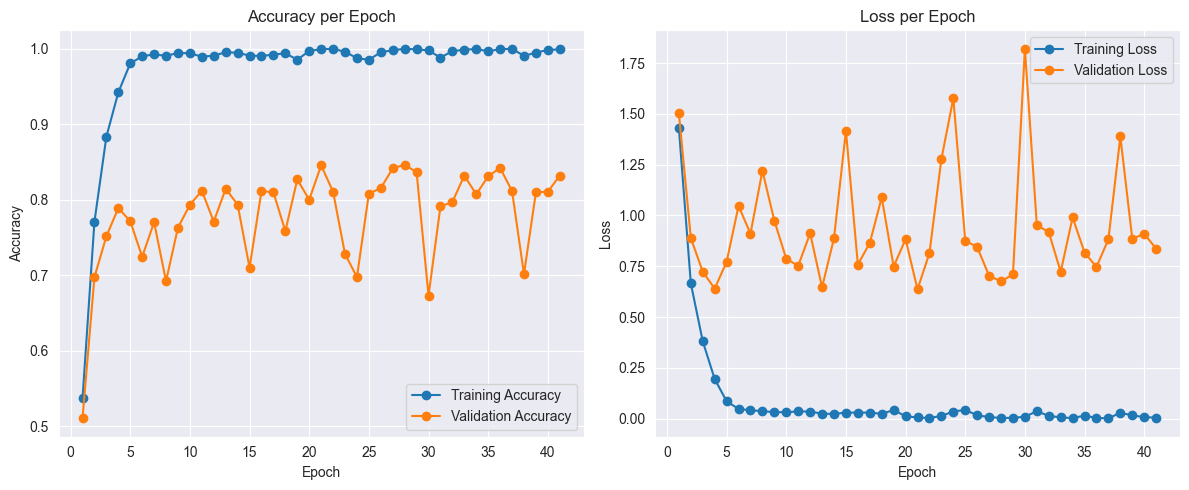

In [ ]:
import matplotlib.pyplot as plt

# Ekstrak history
acc = history_model.history['accuracy']
val_acc = history_model.history['val_accuracy']
loss = history_model.history['loss']
val_loss = history_model.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Akurasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
train_score = model_cnn.evaluate(train_data)
valid_score = model_cnn.evaluate(val_data)
test_score = model_cnn.evaluate(test_data)

print(f"Train Loss: {train_score[0]:.2f}")
print(f"Train Accuracy: {train_score[1]:.2f}")
print('-' * 30)
print(f"Validation Loss: {valid_score[0]:.2f}")
print(f"Validation Accuracy: {valid_score[1]:.2f}")
print('-' * 30)
print(f"Test Loss: {test_score[0]:.2f}")
print(f"Test Accuracy: {test_score[1]:.2f}")

258/258 ━━━━━━━━━━━━━━━━━━━━ 54s 210ms/step - accuracy: 0.9999 - loss: 0.0017
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - accuracy: 0.8404 - loss: 0.6531
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - accuracy: 0.8490 - loss: 0.6679
Train Loss: 0.00
Train Accuracy: 1.00
------------------------------
Validation Loss: 0.64
Validation Accuracy: 0.85
------------------------------
Test Loss: 0.63
Test Accuracy: 0.85


# **Model Convert**

In [ ]:
# Simpan ke folder SavedModel
model_cnn.export('saved_model/my_model')

INFO:tensorflow:Assets written to: saved_model/my_model\assets


INFO:tensorflow:Assets written to: saved_model/my_model\assets


Saved artifact at 'saved_model/my_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  2456765320656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765321040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765321808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765322000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765321424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765320848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765323344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765324880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765324688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765323728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2456765323536: TensorSpec(shap

In [ ]:
# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model/my_model')
tflite_model = converter.convert()

# Simpan file .tflite
with open('saved_model/my_model.tflite', 'wb') as f:
    f.write(tflite_model)


In [ ]:
import tensorflowjs as tfjs

# Simpan model ke TFJS format
tfjs.converters.save_keras_model(model_cnn, 'saved_model/my_model_tfjs')
